# Daily Challenge: Pokemon Win Prediction Analysis

**Goal:** Predict each Pokemon's battle **win percentage** from its stats.

**Pipeline**
1. **Data Preparation** — load & merge `pokemon.csv` + `combats.csv`, fix missing values, compute win %.
2. **Exploratory Analysis & Visualization** — correlation matrix, pairplot, top-10 Pokemon.
3. **Machine Learning** — train/test split, 3+ regression models, compare with MAE.
4. **Dimensionality Reduction** — PCA on the stats.

## 0. Imports

In [1]:
# --- Data handling ---
import numpy as np                 # numerical arrays / math
import pandas as pd                # tabular data (DataFrames)

# --- Visualization ---
import matplotlib.pyplot as plt    # base plotting library
import seaborn as sns              # high-level statistical plots

# --- Machine learning (scikit-learn) ---
from sklearn.model_selection import train_test_split   # split data into train/test
from sklearn.preprocessing import StandardScaler        # standardize features (mean 0, std 1)
from sklearn.linear_model import LinearRegression       # model 1: linear regression
from sklearn.svm import SVR                              # model 2: support vector regression
from sklearn.tree import DecisionTreeRegressor           # model 3: decision tree
from sklearn.ensemble import RandomForestRegressor       # model 4: random forest
from sklearn.decomposition import PCA                    # dimensionality reduction
from sklearn.metrics import mean_absolute_error, r2_score  # evaluation metrics
from xgboost import XGBRegressor                          # model 5: gradient boosting

# Global style: clean white grid for all seaborn plots, and show every DataFrame column
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Data Preparation

### 1.1 Load the data

In [2]:
# Load the two source files:
#   pokemon.csv  -> one row per Pokemon, with its stats (HP, Attack, ...)
#   combats.csv  -> one row per battle, with the two fighters and the winner's id
pokemon = pd.read_csv("pokemon.csv")
combats = pd.read_csv("combats.csv")

print("pokemon:", pokemon.shape)   # (rows, columns)
print("combats:", combats.shape)
pokemon.head()                     # preview the first 5 Pokemon

pokemon: (800, 12)
combats: (50000, 3)


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [3]:
# Preview the battle log: each row = First_pokemon vs Second_pokemon, Winner = id that won
combats.head()

,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


### 1.2 Inspect missing values

In [4]:
# Count missing (NaN) values in each column to see what needs cleaning
pokemon.isnull().sum()

#               0
Name            1
Type 1          0
Type 2        386
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

Two columns have missing values:
- **Name** — one Pokemon is missing its name. The challenge calls this **Primeape** (the evolution of Mankey).
- **Type 2** — hundreds of Pokemon only have a single type, so `Type 2` is `NaN`.

In [7]:
# Show the single row whose Name is missing, so we can confirm which Pokemon it is
pokemon[pokemon["Name"].isnull()]

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary


### 1.3 Fix missing Name (Primeape) and Type 2

In [8]:
# Fix 1 — the missing Name. In this dataset the unnamed Pokemon sits between
# Mankey (#62) and Growlithe (#64), so it is Primeape.
pokemon.loc[pokemon["Name"].isnull(), "Name"] = "Primeape"

# Fix 2 — Type 2. A NaN here just means the Pokemon has a single type,
# so we replace it with the explicit label "None" (not a real missing value).
pokemon["Type 2"] = pokemon["Type 2"].fillna("None")

# Confirm there are no missing values left, and eyeball the fixed Primeape row
print("Remaining missing values:")
print(pokemon.isnull().sum())
pokemon.iloc[60:64]

Remaining missing values:
#             0
Name          0
Type 1        0
Type 2        0
HP            0
Attack        0
Defense       0
Sp. Atk       0
Sp. Def       0
Speed         0
Generation    0
Legendary     0
dtype: int64


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
60,61,Golduck,Water,None,80,82,78,95,80,85,1,False
61,62,Mankey,Fighting,None,40,80,35,35,45,70,1,False
62,63,Primeape,Fighting,None,65,105,60,60,70,95,1,False
63,64,Growlithe,Fire,None,55,70,45,70,50,60,1,False


### 1.4 Calculate each Pokemon's win percentage

For every Pokemon we count:
- **total battles** = times it appeared as `First_pokemon` + times as `Second_pokemon`,
- **wins** = times its id appears in `Winner`.

$$\text{win\%} = \frac{\text{wins}}{\text{total battles}} \times 100$$

In [9]:
# Step 1 — count how many battles each Pokemon fought in.
# A Pokemon can appear either as the first or the second fighter, so we count both
# and add the two tallies together (fill_value=0 handles ids missing from one side).
fights_first = combats["First_pokemon"].value_counts()
fights_second = combats["Second_pokemon"].value_counts()
total_fights = fights_first.add(fights_second, fill_value=0)

# Step 2 — count how many battles each Pokemon won (its id appears in the Winner column)
wins = combats["Winner"].value_counts()

# Step 3 — combine into one table, indexed by Pokemon id.
# Pokemon that never won get NaN -> fillna(0) turns that into 0 wins.
battle_stats = pd.DataFrame({
    "total_battles": total_fights,
    "wins": wins,
}).fillna(0)

# Step 4 — the target variable: win percentage = wins / total battles * 100
battle_stats["win_pct"] = battle_stats["wins"] / battle_stats["total_battles"] * 100
battle_stats.head()

,total_battles,wins,win_pct
1,133,37.0,27.819549
2,121,46.0,38.016529
3,132,89.0,67.424242
4,125,70.0,56.000000
5,112,55.0,49.107143


### 1.5 Merge battle stats back onto the Pokemon table

In [10]:
# Join the battle stats onto the Pokemon table.
# left_on="#" matches the Pokemon id column; right_index=True matches battle_stats' index (also the id).
df = pokemon.merge(battle_stats, left_on="#", right_index=True, how="left")

# A few Pokemon never appear in combats.csv -> they have no battles and so no win_pct.
missing_battles = df["total_battles"].isnull().sum()
print(f"Pokemon with no recorded battles: {missing_battles}")

# Drop those rows so the model only learns from Pokemon that actually fought
df = df.dropna(subset=["win_pct"]).reset_index(drop=True)
print("Final modelling dataset:", df.shape)
df.head()

Pokemon with no recorded battles: 16
Final modelling dataset: (784, 15)


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,total_battles,wins,win_pct
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,133.0,37.0,27.819549
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,121.0,46.0,38.016529
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,132.0,89.0,67.424242
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,125.0,70.0,56.000000
4,5,Charmander,Fire,None,39,52,43,60,50,65,1,False,112.0,55.0,49.107143


## 2. Exploratory Analysis & Visualization

### 2.1 Distribution of win percentage

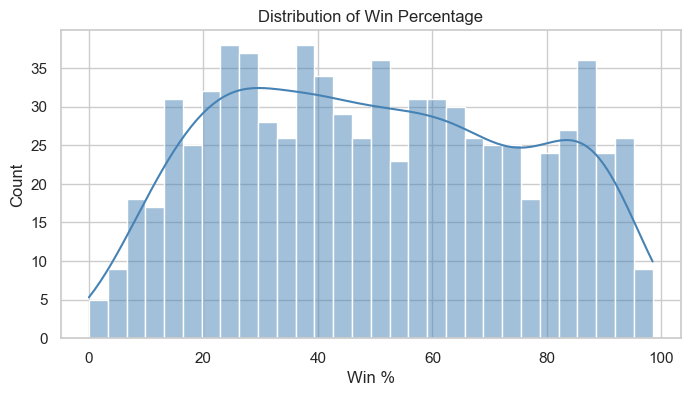

In [11]:
# Histogram (+ KDE curve) to see how win % is spread across all Pokemon
plt.figure(figsize=(8, 4))
sns.histplot(df["win_pct"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Win Percentage")
plt.xlabel("Win %")
plt.show()

### 2.2 Correlation matrix between stats and win percentage

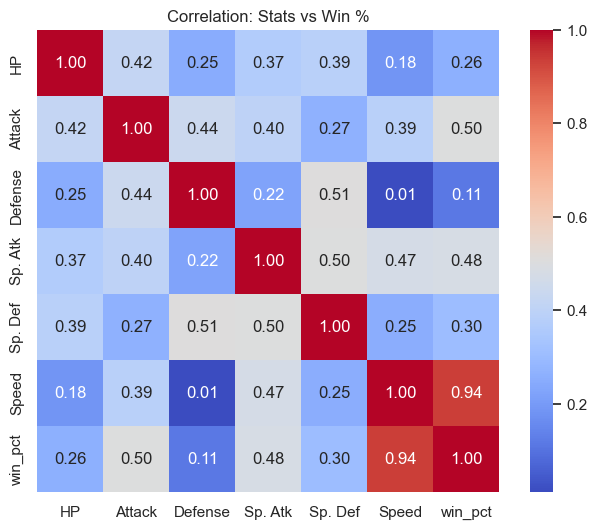

Correlation of each stat with win_pct:
win_pct    1.000000
Speed      0.938055
Attack     0.502825
Sp. Atk    0.481445
Sp. Def    0.302422
HP         0.261602
Defense    0.114565
Name: win_pct, dtype: float64


In [12]:
# Compute pairwise Pearson correlations between the core stats and win %
stat_cols = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed", "win_pct"]
corr = df[stat_cols].corr()

# Heatmap: red = positive correlation, blue = negative; annot prints the numbers
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation: Stats vs Win %")
plt.show()

# Rank the stats by how strongly they correlate with win %
print("Correlation of each stat with win_pct:")
print(corr["win_pct"].sort_values(ascending=False))

**Observation:** `Speed` is by far the strongest driver of win percentage — a faster Pokemon attacks first and wins more often. Attack-related stats follow; Defense and HP matter less.

### 2.3 Pairplot of key stats vs win percentage

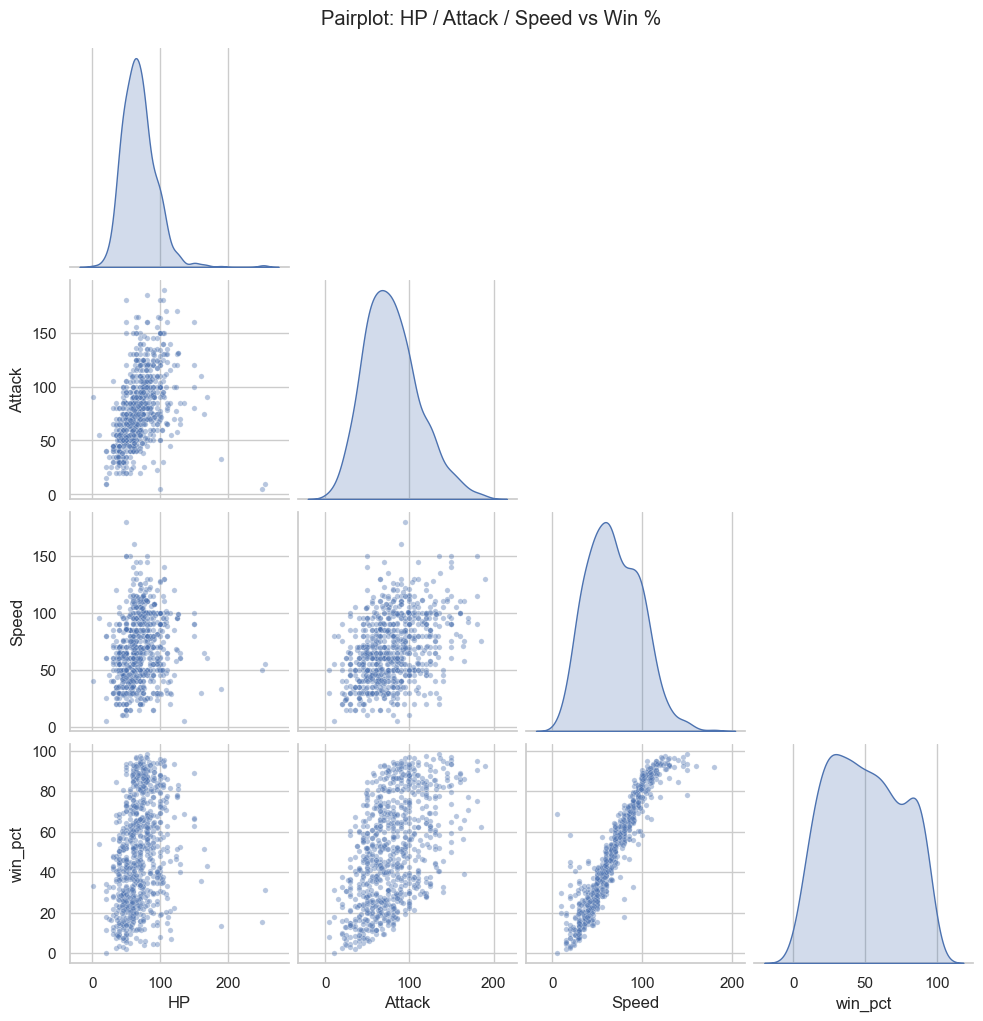

In [13]:
# Pairplot: every pair of these columns as a scatter, with distributions on the diagonal.
# corner=True draws only the lower triangle (avoids duplicate mirrored plots).
pair_cols = ["HP", "Attack", "Speed", "win_pct"]
sns.pairplot(df[pair_cols], diag_kind="kde", corner=True,
             plot_kws={"alpha": 0.4, "s": 15})   # alpha/s = transparency & point size
plt.suptitle("Pairplot: HP / Attack / Speed vs Win %", y=1.02)
plt.show()

### 2.4 Top 10 Pokemon by win percentage

In [14]:
# Sort by win % (highest first) and keep the 10 best Pokemon, showing their stats
top10 = df.sort_values("win_pct", ascending=False).head(10)
top10[["Name", "Type 1", "Type 2", "HP", "Attack", "Defense",
       "Sp. Atk", "Sp. Def", "Speed", "Legendary", "win_pct"]]

,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary,win_pct
147,Mega Aerodactyl,Rock,Flying,80,135,85,70,95,150,False,98.449612
500,Weavile,Dark,Ice,70,120,65,45,85,125,False,97.478992
688,Tornadus Therian Forme,Flying,None,79,100,80,110,90,121,True,96.800000
18,Mega Beedrill,Bug,Poison,65,150,40,15,80,145,False,96.638655
146,Aerodactyl,Rock,Flying,80,105,65,60,75,130,False,96.453901
465,Mega Lopunny,Normal,Fighting,65,136,94,54,96,135,False,96.124031
711,Greninja,Water,Dark,72,95,67,103,71,122,False,96.062992
701,Meloetta Pirouette Forme,Normal,Fighting,100,128,90,77,77,128,False,95.934959
157,Mega Mewtwo Y,Psychic,None,106,150,70,194,120,140,True,95.200000
339,Mega Sharpedo,Water,Dark,70,140,70,110,65,105,False,95.000000


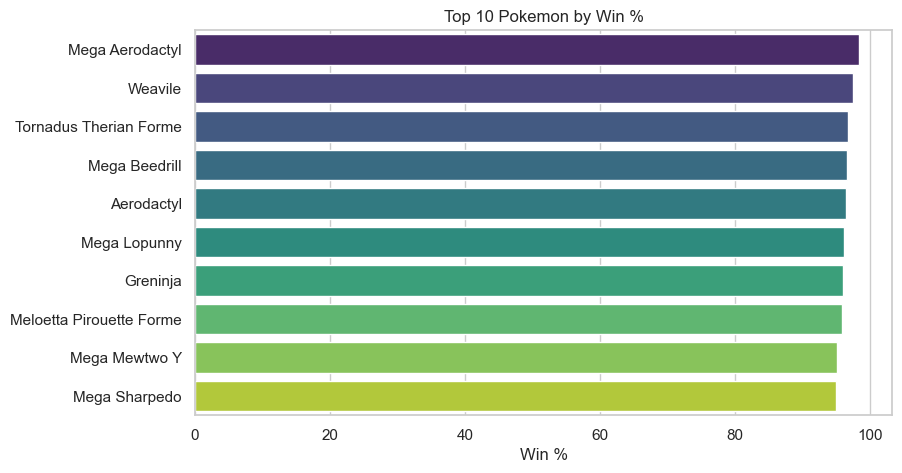

In [15]:
# Horizontal bar chart of the top 10 Pokemon by win %
plt.figure(figsize=(9, 5))
sns.barplot(data=top10, y="Name", x="win_pct", hue="Name", palette="viridis", legend=False)
plt.title("Top 10 Pokemon by Win %")
plt.xlabel("Win %")
plt.ylabel("")
plt.show()

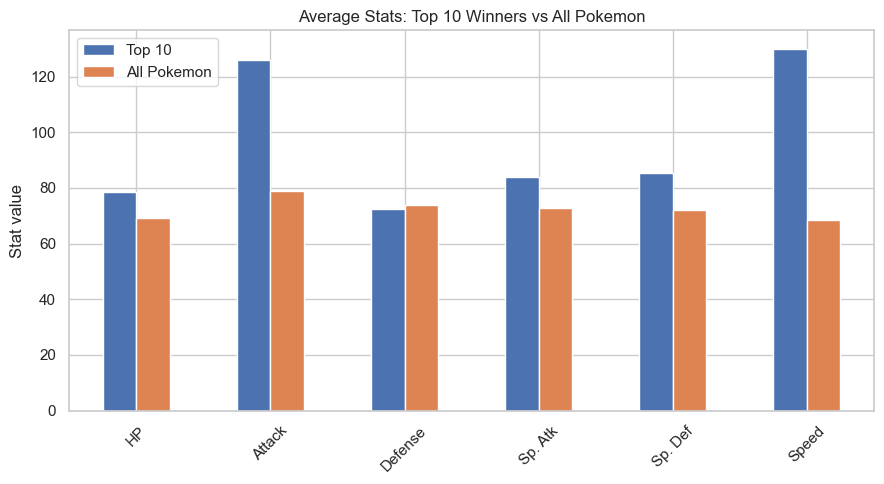

,Top 10,All Pokemon
HP,78.7,69.077806
Attack,125.9,78.919643
Defense,72.6,73.899235
Sp. Atk,83.8,72.758929
Sp. Def,85.4,71.951531
Speed,130.1,68.362245


In [16]:
# Compare the average stats of the top-10 winners against the average of ALL Pokemon.
# This shows which stats the best Pokemon are strongest in.
comparison = pd.DataFrame({
    "Top 10": top10[["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]].mean(),
    "All Pokemon": df[["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]].mean(),
})
comparison.plot(kind="bar", figsize=(9, 5))
plt.title("Average Stats: Top 10 Winners vs All Pokemon")
plt.ylabel("Stat value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
comparison

### 2.5 Does being Legendary help?

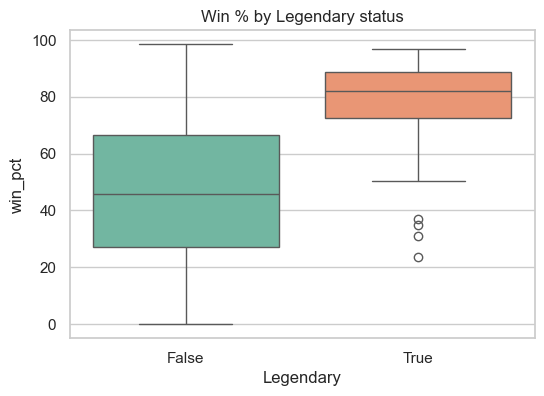

Legendary
False    47.616630
True     77.913661
Name: win_pct, dtype: float64

In [17]:
# Boxplot comparing win % for Legendary vs non-Legendary Pokemon.
# The box shows the median and spread; this reveals if Legendaries win more.
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Legendary", y="win_pct", hue="Legendary", palette="Set2", legend=False)
plt.title("Win % by Legendary status")
plt.show()

# Exact average win % for each group
df.groupby("Legendary")["win_pct"].mean()

## 3. Feature Engineering

We build the feature matrix from the numeric battle-relevant stats. We add a couple of engineered features and encode `Legendary` as 0/1.

In [18]:
# Work on a copy so the original df (used for EDA) stays untouched
model_df = df.copy()

# Engineered features — combine raw stats into more informative ones:
model_df["total_stats"] = model_df[["HP", "Attack", "Defense",
                                    "Sp. Atk", "Sp. Def", "Speed"]].sum(axis=1)  # overall strength
model_df["attack_power"] = model_df["Attack"] + model_df["Sp. Atk"]    # combined offense
model_df["defense_power"] = model_df["Defense"] + model_df["Sp. Def"]  # combined defense

# Convert the boolean Legendary flag to an integer (0/1) so models can use it
model_df["Legendary"] = model_df["Legendary"].astype(int)

# Columns the model will learn from (X) and the value it predicts (y)
feature_cols = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed",
                "Generation", "Legendary",
                "total_stats", "attack_power", "defense_power"]

X = model_df[feature_cols]   # feature matrix
y = model_df["win_pct"]      # target

print("X:", X.shape, "| y:", y.shape)
X.head()

X: (784, 11) | y: (784,)


,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,total_stats,attack_power,defense_power
0,45,49,49,65,65,45,1,0,318,114,114
1,60,62,63,80,80,60,1,0,405,142,143
2,80,82,83,100,100,80,1,0,525,182,183
3,80,100,123,122,120,80,1,0,625,222,243
4,39,52,43,60,50,65,1,0,309,112,93


## 4. Machine Learning

### 4.1 Train / test split (80 / 20) and scaling

In [19]:
# 80% of the data for training, 20% held out for testing.
# random_state=42 makes the split reproducible (same rows every run).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features to mean 0 / std 1.
# IMPORTANT: fit the scaler on TRAIN only, then apply it to test — this avoids
# leaking information from the test set into training. SVM especially needs this.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn mean/std AND transform train
X_test_scaled = scaler.transform(X_test)          # apply the same transform to test

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (627, 11) | Test: (157, 11)


### 4.2 Train and evaluate the models

We compare five regressors — **Linear Regression, SVM (RBF), Decision Tree, Random Forest and XGBoost** — and rank them by **Mean Absolute Error (MAE)** on the test set.

In [20]:
# Five regression models to compare, kept in a dict so we can loop over them
models = {
    "Linear Regression": LinearRegression(),                              # simple linear baseline
    "SVM (RBF)": SVR(kernel="rbf", C=10),                                 # non-linear kernel model
    "Decision Tree": DecisionTreeRegressor(max_depth=6, random_state=42),  # single tree (depth-limited)
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),  # ensemble of trees
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.05,         # gradient-boosted trees
                            max_depth=4, random_state=42),
}

results = []          # will hold one {Model, MAE, R2} dict per model
predictions = {}      # will hold each model's test-set predictions

# Train every model on the same data and score it on the test set
for name, model in models.items():
    model.fit(X_train_scaled, y_train)            # train
    y_pred = model.predict(X_test_scaled)         # predict on unseen test data
    predictions[name] = y_pred
    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),   # avg absolute error (lower = better)
        "R2": r2_score(y_test, y_pred),                # variance explained (closer to 1 = better)
    })

# Build a results table sorted from best (lowest MAE) to worst
results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
results_df

,Model,MAE,R2
0,Random Forest,4.376129,0.938507
1,XGBoost,4.525918,0.940764
2,Decision Tree,4.711654,0.931758
3,SVM (RBF),5.806328,0.896678
4,Linear Regression,6.226518,0.873388


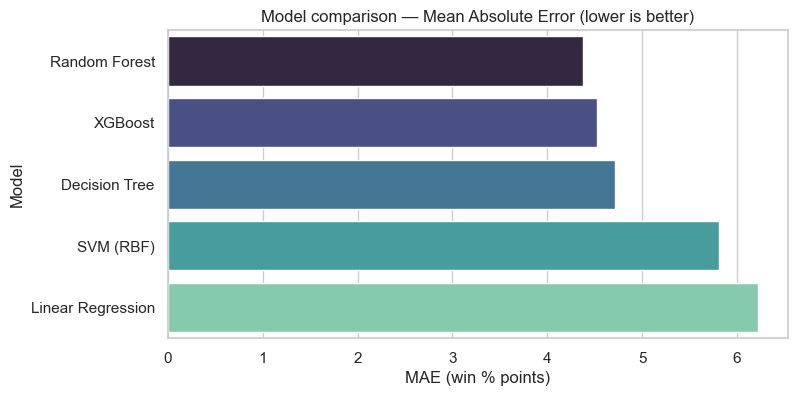

In [21]:
# Bar chart of MAE per model — shorter bars are better models
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="MAE", y="Model", hue="Model", palette="mako", legend=False)
plt.title("Model comparison — Mean Absolute Error (lower is better)")
plt.xlabel("MAE (win % points)")
plt.show()

### 4.3 Predicted vs actual for the best model

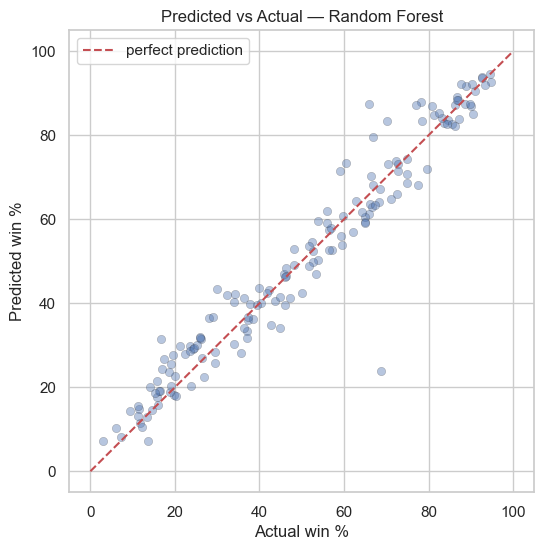

In [22]:
# Take the best model (first row, since results_df is sorted by MAE) and its predictions
best_name = results_df.iloc[0]["Model"]
y_pred_best = predictions[best_name]

# Scatter actual vs predicted win %. Points near the red diagonal = accurate predictions.
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.4, edgecolor="k", linewidth=0.3)
lims = [0, 100]
plt.plot(lims, lims, "r--", label="perfect prediction")   # y = x reference line
plt.xlabel("Actual win %")
plt.ylabel("Predicted win %")
plt.title(f"Predicted vs Actual — {best_name}")
plt.legend()
plt.show()

### 4.4 Feature importance (Random Forest)

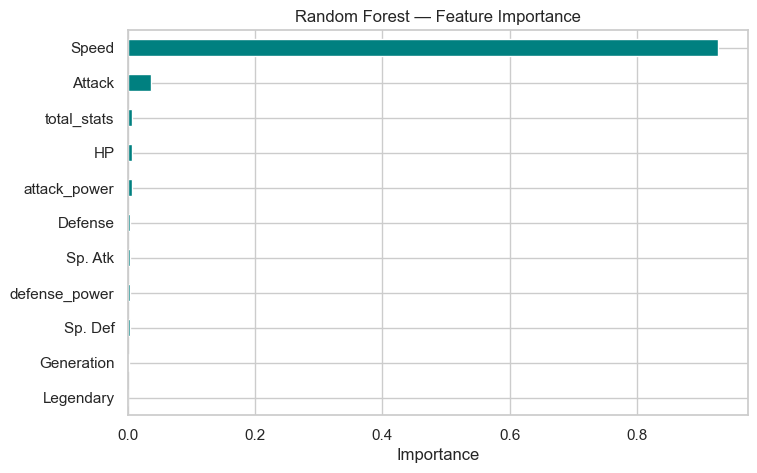

In [23]:
# Random Forest reports how much each feature contributed to its predictions.
# Sorting ascending puts the most important feature at the top of the horizontal bar chart.
rf = models["Random Forest"]
importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()

plt.figure(figsize=(8, 5))
importance.plot(kind="barh", color="teal")
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance")
plt.show()

As expected from the correlation analysis, **Speed** dominates the prediction of win percentage.

## 5. Dimensionality Reduction with PCA

We project the (scaled) features onto principal components to see how much variance a few components capture, and visualise the Pokemon in 2D coloured by win percentage.

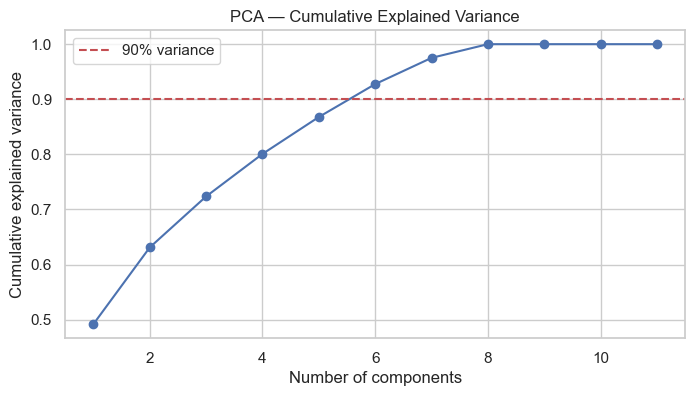

Explained variance ratio: [0.492 0.139 0.093 0.077 0.067 0.06  0.048 0.025 0.    0.    0.   ]


In [24]:
# PCA needs standardized data, so scale the full feature set first
X_all_scaled = StandardScaler().fit_transform(X)

# Fit PCA keeping ALL components, so we can study how much variance each one captures
pca = PCA()
pca.fit(X_all_scaled)

# Cumulative variance explained as we add more components
explained = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained) + 1), explained, marker="o")
plt.axhline(0.9, color="r", linestyle="--", label="90% variance")  # reference: 90% threshold
plt.title("PCA — Cumulative Explained Variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.legend()
plt.show()

# Variance captured by each individual component
print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))

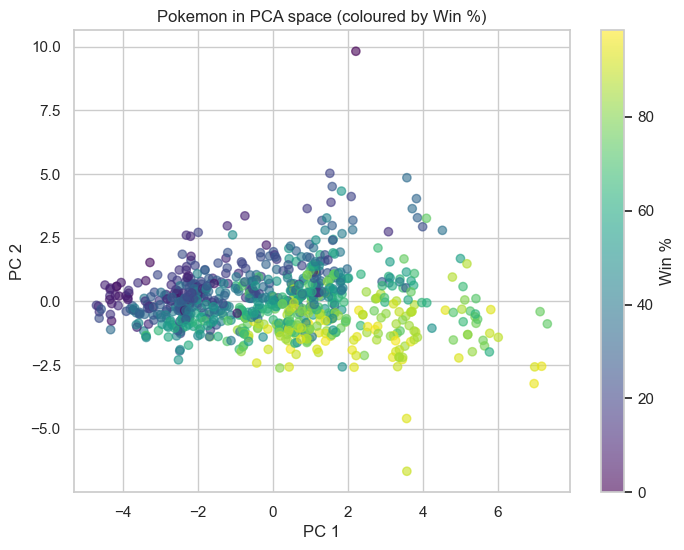

In [25]:
# Reduce the features to just 2 components so we can plot them on a flat scatter
pca2 = PCA(n_components=2)
coords = pca2.fit_transform(X_all_scaled)

# Each point is a Pokemon in 2D PCA space, coloured by its win %.
# A smooth colour gradient means the stats separate weak/strong Pokemon well.
plt.figure(figsize=(8, 6))
sc = plt.scatter(coords[:, 0], coords[:, 1], c=y, cmap="viridis", alpha=0.6)
plt.colorbar(sc, label="Win %")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("Pokemon in PCA space (coloured by Win %)")
plt.show()

## 6. Conclusion

- **Data prep:** merged 50,000 battles onto the Pokemon table, filled the missing name (**Primeape**) and `Type 2` (**None**), and derived each Pokemon's **win percentage**.
- **EDA:** **Speed** is the single strongest predictor of winning — confirmed by the correlation matrix, the pairplot and the Random-Forest feature importance. Legendary Pokemon win noticeably more often.
- **Modelling:** of the five regressors (Linear Regression, SVM, Decision Tree, Random Forest, XGBoost), the ensemble / boosted models (**Random Forest** and **XGBoost**) gave the lowest **MAE** and highest **R²**, predicting win percentage to within ~4.4 percentage points.
- **PCA:** the first few principal components already explain most of the variance, and the 2D projection shows a clear win-percentage gradient — the stats carry strong, low-dimensional signal.